Below is a **full, correct, notebook-style block split into a few cells**. It is:

- **strictly aligned with your LaTeX note**
- **MPO-based**
- **matrix-free**
- uses **Lanczos via `eigsh`**
- includes:
  - MPO validation
  - small ED benchmarks
  - exact AKLT MPS benchmark
  - one-site and two-site projected-operator tests
  - production Heisenberg and AKLT runs
  - memory-safe observable plots
  - figures saved to `figureAKLT`
- includes the **robust fast solver fallback**


=== MPO validation ===
Heisenberg L=2: err=0.000e+00
Heisenberg L=3: err=6.206e-17
Heisenberg L=4: err=2.559e-16
AKLT       L=2: err=7.611e-16
AKLT       L=3: err=2.184e-15
AKLT       L=4: err=5.379e-15

=== Small-system ED benchmarks ===
Heisenberg L=8: DMRG=-3.374932598688, ED=-3.374932598688, err=1.332e-15
AKLT       L=8: DMRG=-4.666666666667, ED=-4.666666666667, err=2.132e-14

=== AKLT exact MPS benchmark ===
L=4: E(MPS)=-2.000000000000, exact=-2.000000000000, err=4.441e-16
L=6: E(MPS)=-3.333333333333, exact=-3.333333333333, err=8.882e-16
L=8: E(MPS)=-4.666666666667, exact=-4.666666666667, err=8.882e-16

=== One-site projected-operator validation ===
One-site projected-operator validation for Heisenberg: L=6, site=2
Nloc = 48
||H_env - H_exact|| = 2.720794e-15
relative error      = 4.410473e-16
Hermiticity env     = 2.106799e-15
Hermiticity exact   = 1.533234e-15

=== Two-site projected-operator validation ===
Two-site projected-operator validation for Heisenberg: L=6, bond=(2,3)
N

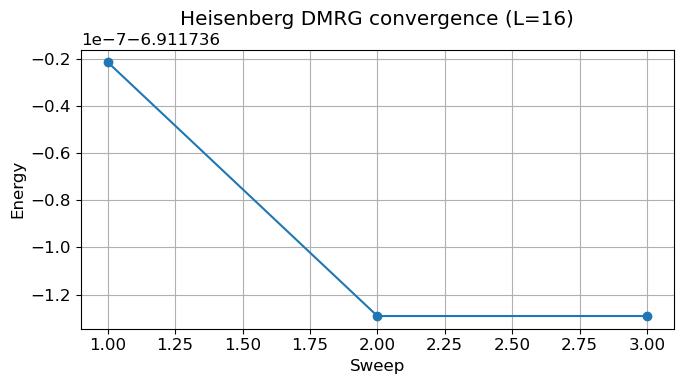

Saved: figureAKLT\aklt_energy_convergence.png


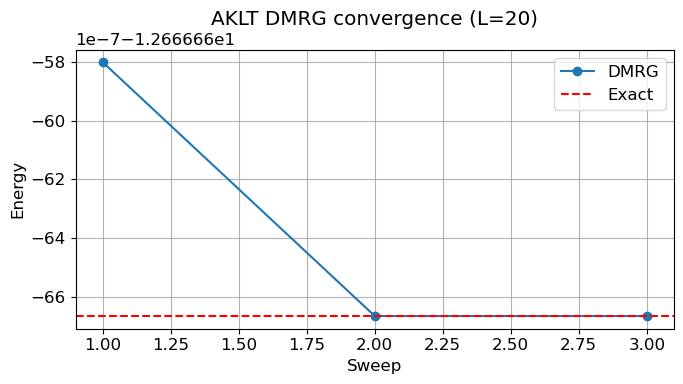

Saved: figureAKLT\heisenberg_discarded_weight.png


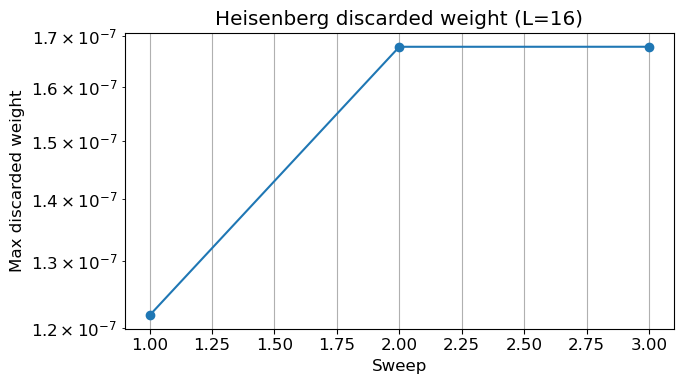

Saved: figureAKLT\aklt_discarded_weight.png


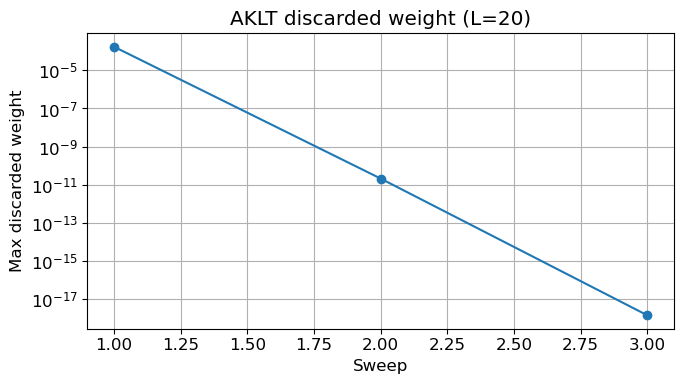

Saved: figureAKLT\heisenberg_entanglement_entropy.png


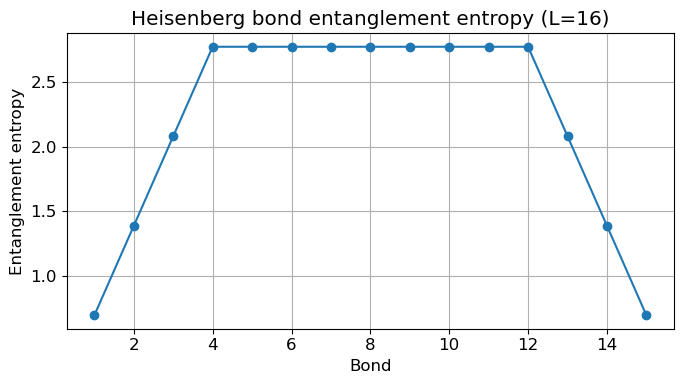

Saved: figureAKLT\aklt_entanglement_entropy.png


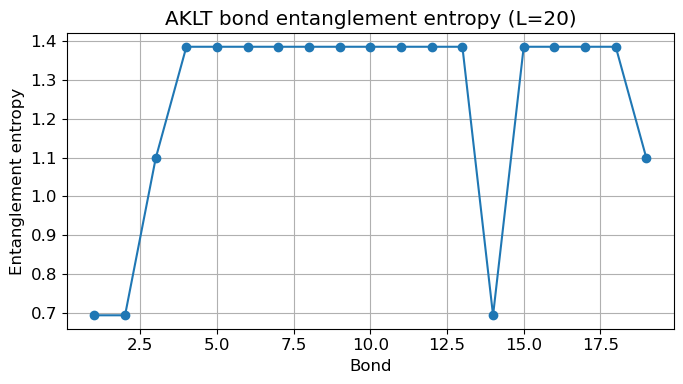

Saved: figureAKLT\heisenberg_local_magnetization.png


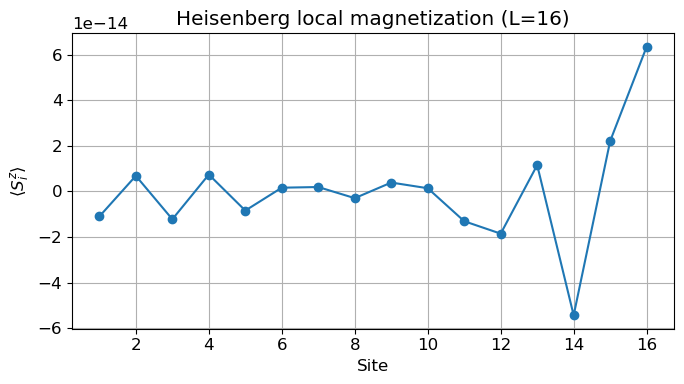

Saved: figureAKLT\aklt_local_magnetization.png


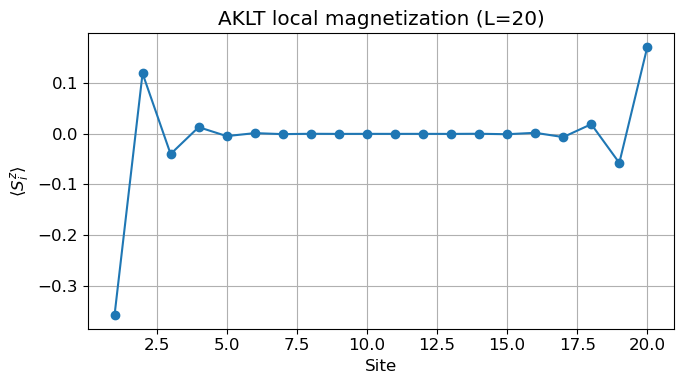

Saved: figureAKLT\aklt_exact_energy_vs_L.png


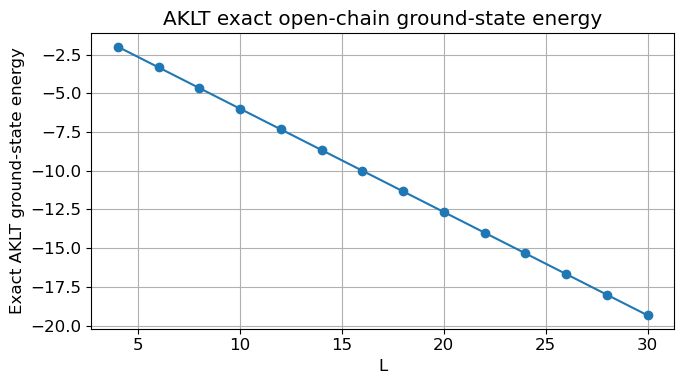

All figures saved to: figureAKLT


In [17]:
# CELL 1 — Imports and setup

import os
import numpy as np
import scipy.linalg as la
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import ArpackNoConvergence
import matplotlib.pyplot as plt

np.set_printoptions(precision=12, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 12

FIGDIR = "figureAKLT"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIGDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)


# CELL 2 — Operators, dense references, MPOs

# ============================================================
# Local operators
# ============================================================
def spin_half_ops(dtype=np.complex128):
    I = np.eye(2, dtype=dtype)
    Sp = np.array([[0, 1],
                   [0, 0]], dtype=dtype)
    Sm = np.array([[0, 0],
                   [1, 0]], dtype=dtype)
    Sz = 0.5 * np.array([[1, 0],
                         [0, -1]], dtype=dtype)
    Sx = 0.5 * (Sp + Sm)
    Sy = (Sp - Sm) / (2j)
    return I, Sp, Sm, Sz, Sx, Sy

def spin_one_ops(dtype=np.complex128):
    I = np.eye(3, dtype=dtype)
    Sp = np.sqrt(2) * np.array([[0, 1, 0],
                                [0, 0, 1],
                                [0, 0, 0]], dtype=dtype)
    Sm = np.sqrt(2) * np.array([[0, 0, 0],
                                [1, 0, 0],
                                [0, 1, 0]], dtype=dtype)
    Sz = np.array([[1, 0, 0],
                   [0, 0, 0],
                   [0, 0, -1]], dtype=dtype)
    Sx = 0.5 * (Sp + Sm)
    Sy = (Sp - Sm) / (2j)
    return I, Sp, Sm, Sz, Sx, Sy


# ============================================================
# Dense reference Hamiltonians
# ============================================================
def kron_all(op_list):
    out = op_list[0]
    for op in op_list[1:]:
        out = np.kron(out, op)
    return out

def dense_heisenberg_xxz(L, J=1.0, Jz=1.0, h=0.0, dtype=np.complex128):
    I, Sp, Sm, Sz, _, _ = spin_half_ops(dtype=dtype)
    H = np.zeros((2**L, 2**L), dtype=dtype)

    for i in range(L - 1):
        ops = [I] * L
        ops[i] = Sp
        ops[i + 1] = Sm
        H += 0.5 * J * kron_all(ops)

        ops = [I] * L
        ops[i] = Sm
        ops[i + 1] = Sp
        H += 0.5 * J * kron_all(ops)

        ops = [I] * L
        ops[i] = Sz
        ops[i + 1] = Sz
        H += Jz * kron_all(ops)

    for i in range(L):
        ops = [I] * L
        ops[i] = Sz
        H += -h * kron_all(ops)

    return H

def dense_aklt(L, dtype=np.complex128):
    I, Sp, Sm, Sz, Sx, Sy = spin_one_ops(dtype=dtype)
    d = 3
    H = np.zeros((d**L, d**L), dtype=dtype)

    for i in range(L - 1):
        X = np.zeros((d**L, d**L), dtype=dtype)
        for A, B in [(Sx, Sx), (Sy, Sy), (Sz, Sz)]:
            ops = [I] * L
            ops[i] = A
            ops[i + 1] = B
            X += kron_all(ops)
        H += X + (1.0 / 3.0) * (X @ X)

    return H

def exact_ground_state_energy(H):
    return np.min(la.eigh(H, eigvals_only=True))


# ============================================================
# MPOs exactly as in the note
# Convention: W[a,b,s,t], s=ket, t=bra
# ============================================================
def mpo_heisenberg_xxz(L, J=1.0, Jz=1.0, h=0.0, dtype=np.complex128):
    I, Sp, Sm, Sz, _, _ = spin_half_ops(dtype=dtype)
    d = 2
    chi = 5

    Wbulk = np.zeros((chi, chi, d, d), dtype=dtype)
    Wbulk[0, 0] = I
    Wbulk[1, 0] = Sp
    Wbulk[2, 0] = Sm
    Wbulk[3, 0] = Sz
    Wbulk[4, 0] = -h * Sz
    Wbulk[4, 1] = 0.5 * J * Sm
    Wbulk[4, 2] = 0.5 * J * Sp
    Wbulk[4, 3] = Jz * Sz
    Wbulk[4, 4] = I

    Wleft = np.zeros((1, chi, d, d), dtype=dtype)
    Wleft[0, 0] = -h * Sz
    Wleft[0, 1] = 0.5 * J * Sm
    Wleft[0, 2] = 0.5 * J * Sp
    Wleft[0, 3] = Jz * Sz
    Wleft[0, 4] = I

    Wright = np.zeros((chi, 1, d, d), dtype=dtype)
    Wright[0, 0] = I
    Wright[1, 0] = Sp
    Wright[2, 0] = Sm
    Wright[3, 0] = Sz
    Wright[4, 0] = -h * Sz

    mpo = [None] * L
    mpo[0] = Wleft
    for i in range(1, L - 1):
        mpo[i] = Wbulk.copy()
    mpo[L - 1] = Wright
    return mpo

def mpo_aklt(L, dtype=np.complex128):
    I, Sp, Sm, Sz, _, _ = spin_one_ops(dtype=dtype)
    d = 3
    chi = 14

    O = [Sp / np.sqrt(2), Sm / np.sqrt(2), Sz]
    Obar = [Sm / np.sqrt(2), Sp / np.sqrt(2), Sz]
    O2 = [O[a] @ O[b] for a in range(3) for b in range(3)]
    Obar2 = [Obar[a] @ Obar[b] for a in range(3) for b in range(3)]

    Wbulk = np.zeros((chi, chi, d, d), dtype=dtype)
    Wbulk[0, 0] = I
    for a in range(3):
        Wbulk[0, 1 + a] = O[a]
    for k in range(9):
        Wbulk[0, 4 + k] = (1.0 / 3.0) * O2[k]
    for a in range(3):
        Wbulk[1 + a, 13] = Obar[a]
    for k in range(9):
        Wbulk[4 + k, 13] = Obar2[k]
    Wbulk[13, 13] = I

    Wleft = np.zeros((1, chi, d, d), dtype=dtype)
    Wleft[0, 0] = I
    for a in range(3):
        Wleft[0, 1 + a] = O[a]
    for k in range(9):
        Wleft[0, 4 + k] = (1.0 / 3.0) * O2[k]

    Wright = np.zeros((chi, 1, d, d), dtype=dtype)
    for a in range(3):
        Wright[1 + a, 0] = Obar[a]
    for k in range(9):
        Wright[4 + k, 0] = Obar2[k]
    Wright[13, 0] = I

    mpo = [None] * L
    mpo[0] = Wleft
    for i in range(1, L - 1):
        mpo[i] = Wbulk.copy()
    mpo[L - 1] = Wright
    return mpo


# ============================================================
# Correct MPO -> dense contraction
# ============================================================
def mpo_to_dense(mpo):
    cur = mpo[0][0].copy()
    for i in range(1, len(mpo)):
        W = mpo[i]
        chi_prev, K, B = cur.shape
        chiL, chiR, d, db = W.shape
        assert chi_prev == chiL
        tmp = np.einsum("aKB,abst->bKsBt", cur, W)
        cur = tmp.reshape((chiR, K * d, B * db), order="C")
    assert cur.shape[0] == 1
    return cur[0]


# CELL 3 — MPS utilities, environments, matrix-free local solvers, fast DMRG

# ============================================================
# MPS utilities
# ============================================================
def random_mps(L, d, Dmax, seed=None, dtype=np.complex128):
    rng = np.random.default_rng(seed)
    dims = [1] + [min(Dmax, d**min(i, L - i)) for i in range(1, L)] + [1]
    mps = []
    for i in range(L):
        Dl, Dr = dims[i], dims[i + 1]
        A = rng.normal(size=(Dl, d, Dr)) + 1j * rng.normal(size=(Dl, d, Dr))
        mps.append(A.astype(dtype))
    return mps

def mps_norm(mps):
    env = np.array([[1.0 + 0j]])
    for A in mps:
        env = np.einsum("xy,xsa,ysb->ab", env, A, A.conj())
    return np.real_if_close(env[0, 0])

def left_canonicalize(mps):
    mps = [A.copy() for A in mps]
    for i in range(len(mps) - 1):
        Dl, d, Dr = mps[i].shape
        M = mps[i].reshape((Dl * d, Dr), order="C")
        Q, R = la.qr(M, mode="economic")
        k = Q.shape[1]
        mps[i] = Q.reshape((Dl, d, k), order="C")
        mps[i + 1] = np.einsum("ab,bsd->asd", R, mps[i + 1])
    return mps

def prepare_initial_mps(L, d, Dinit=8, seed=1234):
    mps = random_mps(L, d, Dinit, seed=seed)
    mps = left_canonicalize(mps)
    nrm = mps_norm(mps)
    mps[-1] /= np.sqrt(nrm)
    return mps

def mps_to_dense(mps):
    psi = mps[0][0, :, :]
    for i in range(1, len(mps)):
        A = mps[i]
        psi = np.einsum("Pa,asb->Psb", psi, A)
        psi = psi.reshape((-1, psi.shape[-1]), order="C")
    assert psi.shape[-1] == 1
    return psi[:, 0]

def mps_mpo_expectation(mps, mpo):
    env = np.zeros((1, 1, 1), dtype=np.complex128)
    env[0, 0, 0] = 1.0
    for A, W in zip(mps, mpo):
        env = np.einsum("bxy,xsa,bBst,ytc->Bac", env, A, W, A.conj())
    return np.real_if_close(env[0, 0, 0])

def mixed_canonical_for_site(mps, site):
    mps = [A.copy() for A in mps]
    L = len(mps)
    mps = left_canonicalize(mps)
    for i in range(L - 1, site, -1):
        Dl, d, Dr = mps[i].shape
        M = mps[i].reshape((Dl, d * Dr), order="C")
        Q, R = la.qr(M.conj().T, mode="economic")
        B = Q.conj().T.reshape((Q.shape[1], d, Dr), order="C")
        mps[i] = B
        mps[i - 1] = np.einsum("asd,db->asb", mps[i - 1], R.conj().T)
    return mps

def mixed_canonical_for_bond(mps, bond):
    mps = [A.copy() for A in mps]
    L = len(mps)
    mps = left_canonicalize(mps)
    for i in range(L - 1, bond + 1, -1):
        Dl, d, Dr = mps[i].shape
        M = mps[i].reshape((Dl, d * Dr), order="C")
        Q, R = la.qr(M.conj().T, mode="economic")
        B = Q.conj().T.reshape((Q.shape[1], d, Dr), order="C")
        mps[i] = B
        mps[i - 1] = np.einsum("asd,db->asb", mps[i - 1], R.conj().T)
    return mps


# ============================================================
# Environments exactly as in the note
# ============================================================
def init_left_boundary():
    L = np.zeros((1, 1, 1), dtype=np.complex128)
    L[0, 0, 0] = 1.0
    return L

def init_right_boundary():
    R = np.zeros((1, 1, 1), dtype=np.complex128)
    R[0, 0, 0] = 1.0
    return R

def left_env_update(Lenv, A, W):
    return np.einsum("bxy,xsa,bBst,ytc->Bac", Lenv, A, W, A.conj())

def right_env_update(Renv, B, W):
    return np.einsum("xsa,bBst,Bac,ytc->bxy", B, W, Renv, B.conj())

def build_all_right_envs(mps, mpo):
    L = len(mps)
    Renvs = [None] * L
    R = init_right_boundary()
    Renvs[L - 1] = R
    for i in range(L - 2, -1, -1):
        R = right_env_update(R, mps[i + 1], mpo[i + 1])
        Renvs[i] = R
    return Renvs


# ============================================================
# Matrix-free local effective Hamiltonians exactly as in the note
# ============================================================
def heff_one_site_matvec(v, Lenv, W, Renv, Dl, d, Dr):
    M = v.reshape((Dl, d, Dr), order="C")
    X  = np.einsum("byx,ysz->bxsz", Lenv, M)
    Y  = np.einsum("bBst,bxsz->Bxtz", W, X)
    HM = np.einsum("Bxtz,Bza->xta", Y, Renv)
    return HM.reshape(Dl * d * Dr, order="C")

def heff_two_site_matvec(v, Lenv, W1, W2, Renv, Dl, d1, d2, Dr):
    Theta = v.reshape((Dl, d1, d2, Dr), order="C")
    X  = np.einsum("byx,yuvz->bxuvz", Lenv, Theta)
    Y  = np.einsum("bBus,bxuvz->Bxsvz", W1, X)
    Z  = np.einsum("BCvt,Bxsvz->Cxstz", W2, Y)
    HT = np.einsum("Cxstz,Cza->xsta", Z, Renv)
    return HT.reshape(Dl * d1 * d2 * Dr, order="C")


# ============================================================
# Robust fast local eigensolver
# ============================================================
def two_site_ground_state_fast(Lenv, W1, W2, Renv, Theta0,
                               tol=1e-8, maxiter=300, ncv=None):
    Dl, d1, d2, Dr = Theta0.shape
    Nloc = Dl * d1 * d2 * Dr

    Hop = spla.LinearOperator(
        shape=(Nloc, Nloc),
        matvec=lambda v: heff_two_site_matvec(v, Lenv, W1, W2, Renv, Dl, d1, d2, Dr),
        dtype=np.complex128
    )

    v0 = Theta0.reshape(Nloc, order="C")

    if ncv is None:
        ncv = min(max(20, 10), Nloc)

    try:
        vals, vecs = spla.eigsh(
            Hop,
            k=1,
            which="SA",
            v0=v0,
            tol=tol,
            maxiter=maxiter,
            ncv=ncv
        )
        return np.real(vals[0]), vecs[:, 0].reshape((Dl, d1, d2, Dr), order="C")

    except ArpackNoConvergence:
        ncv2 = min(max(2 * ncv, 40), Nloc)
        vals, vecs = spla.eigsh(
            Hop,
            k=1,
            which="SA",
            v0=v0,
            tol=max(tol, 1e-8),
            maxiter=maxiter * 4,
            ncv=ncv2
        )
        return np.real(vals[0]), vecs[:, 0].reshape((Dl, d1, d2, Dr), order="C")


# ============================================================
# Truncation
# ============================================================
def svd_truncate_theta(Theta, Dmax, cutoff=1e-12, direction="lr"):
    Dl, d1, d2, Dr = Theta.shape
    M = Theta.reshape((Dl * d1, d2 * Dr), order="C")
    U, s, Vh = la.svd(M, full_matrices=False)

    keep = np.sum(s > cutoff)
    keep = max(1, min(Dmax, keep, len(s)))
    disc = np.sum(s[keep:]**2).real

    U = U[:, :keep]
    s = s[:keep]
    Vh = Vh[:keep, :]

    if direction == "lr":
        A = U.reshape((Dl, d1, keep), order="C")
        B = (np.diag(s) @ Vh).reshape((keep, d2, Dr), order="C")
    elif direction == "rl":
        A = (U @ np.diag(s)).reshape((Dl, d1, keep), order="C")
        B = Vh.reshape((keep, d2, Dr), order="C")
    else:
        raise ValueError("direction must be 'lr' or 'rl'")

    return A, B, s, disc


# ============================================================
# Faster two-site DMRG
# ============================================================
def dmrg_two_site_fast(mpo, d, Dmax=40, nsweeps=12, cutoff=1e-10,
                       seed=1234, energy_tol=1e-10, lanczos_tol=1e-8,
                       lanczos_maxiter=300, verbose=True):
    L = len(mpo)
    mps = prepare_initial_mps(L, d, Dinit=min(Dmax, 8), seed=seed)

    energies = []
    max_discards = []

    for sweep in range(nsweeps):
        Renvs = build_all_right_envs(mps, mpo)

        Lenvs = [None] * L
        Lenv = init_left_boundary()
        Lenvs[0] = Lenv

        sweep_Es = []
        discards = []

        # left -> right
        for i in range(L - 1):
            Theta = np.einsum("asb,btc->astc", mps[i], mps[i + 1])
            E, Theta_opt = two_site_ground_state_fast(
                Lenv, mpo[i], mpo[i + 1], Renvs[i + 1], Theta,
                tol=lanczos_tol, maxiter=lanczos_maxiter
            )
            A, B, s, dw = svd_truncate_theta(
                Theta_opt, Dmax=Dmax, cutoff=cutoff, direction="lr"
            )
            mps[i] = A
            mps[i + 1] = B

            Lenv = left_env_update(Lenv, mps[i], mpo[i])
            Lenvs[i + 1] = Lenv

            sweep_Es.append(E)
            discards.append(dw)

        # right -> left
        Renv = init_right_boundary()
        for i in range(L - 2, -1, -1):
            Theta = np.einsum("asb,btc->astc", mps[i], mps[i + 1])
            E, Theta_opt = two_site_ground_state_fast(
                Lenvs[i], mpo[i], mpo[i + 1], Renv, Theta,
                tol=lanczos_tol, maxiter=lanczos_maxiter
            )
            A, B, s, dw = svd_truncate_theta(
                Theta_opt, Dmax=Dmax, cutoff=cutoff, direction="rl"
            )
            mps[i] = A
            mps[i + 1] = B

            Renv = right_env_update(Renv, mps[i + 1], mpo[i + 1])

            sweep_Es.append(E)
            discards.append(dw)

        E_last = sweep_Es[-1]
        energies.append(E_last)
        max_discards.append(max(discards) if discards else 0.0)

        if verbose:
            print(f"Sweep {sweep+1:02d}: E = {E_last:.14f}, max discarded = {max_discards[-1]:.3e}")

        if len(energies) >= 2 and abs(energies[-1] - energies[-2]) < energy_tol:
            if verbose:
                print(f"Converged after {sweep+1} sweeps with |ΔE|={abs(energies[-1]-energies[-2]):.3e}")
            break

    return {
        "mps": mps,
        "energies": np.array(energies),
        "max_discards": np.array(max_discards)
    }


# Recommended presets
FAST_HEISENBERG_PARAMS = dict(
    Dmax=16,
    nsweeps=8,
    cutoff=1e-10,
    seed=1234,
    energy_tol=1e-10,
    lanczos_tol=1e-8,
    lanczos_maxiter=300,
    verbose=True
)

FAST_AKLT_PARAMS = dict(
    Dmax=4,
    nsweeps=6,
    cutoff=1e-12,
    seed=1234,
    energy_tol=1e-12,
    lanczos_tol=1e-10,
    lanczos_maxiter=400,
    verbose=True
)

ROBUST_SMALL_AKLT_PARAMS = dict(
    Dmax=12,
    nsweeps=8,
    cutoff=1e-12,
    seed=1,
    energy_tol=1e-12,
    lanczos_tol=1e-10,
    lanczos_maxiter=400,
    verbose=False
)

# CELL 4 — Validation helpers and scalable diagnostics

# ============================================================
# AKLT exact MPS benchmark
# ============================================================
def aklt_exact_mps(L, dtype=np.complex128):
    Aplus = np.array([[0, np.sqrt(2/3)],
                      [0, 0]], dtype=dtype)
    A0 = np.array([[-1/np.sqrt(3), 0],
                   [0, 1/np.sqrt(3)]], dtype=dtype)
    Aminus = np.array([[0, 0],
                       [-np.sqrt(2/3), 0]], dtype=dtype)

    bulk = np.stack([Aplus, A0, Aminus], axis=1)
    mps = []
    for i in range(L):
        if i == 0:
            A = np.zeros((1, 3, 2), dtype=dtype)
            A[0, :, :] = bulk[0, :, :]
        elif i == L - 1:
            A = np.zeros((2, 3, 1), dtype=dtype)
            A[:, :, 0] = bulk[:, :, 0]
        else:
            A = bulk.copy()
        mps.append(A)
    return mps

def aklt_exact_mps_energy(L):
    mps = aklt_exact_mps(L)
    mpo = mpo_aklt(L)
    return np.real(mps_mpo_expectation(mps, mpo) / mps_norm(mps))


# ============================================================
# Projected-operator validation helpers
# ============================================================
def state_from_two_site_tensor(mps, bond, Theta):
    L = len(mps)

    if bond == 0:
        cur = Theta.copy()[0]
    else:
        left = mps[0][0, :, :]
        for i in range(1, bond):
            A = mps[i]
            left = np.einsum("Pa,asb->Psb", left, A)
            left = left.reshape((-1, left.shape[-1]), order="C")
        cur = np.einsum("Pa,astb->Pstb", left, Theta)

    for i in range(bond + 2, L):
        A = mps[i]
        cur = np.einsum("...a,asb->...sb", cur, A)

    return cur.reshape(-1, order="C")

def full_embedding_matrix_two_site(mps, bond):
    Dl = mps[bond].shape[0]
    d1 = mps[bond].shape[1]
    d2 = mps[bond + 1].shape[1]
    Dr = mps[bond + 1].shape[2]

    Nloc = Dl * d1 * d2 * Dr
    Theta0 = np.zeros((Dl, d1, d2, Dr), dtype=np.complex128)
    Nfull = state_from_two_site_tensor(mps, bond, Theta0).size

    P = np.zeros((Nfull, Nloc), dtype=np.complex128)
    for j in range(Nloc):
        Theta = np.zeros((Dl, d1, d2, Dr), dtype=np.complex128)
        Theta.reshape(Nloc, order="C")[j] = 1.0
        P[:, j] = state_from_two_site_tensor(mps, bond, Theta)
    return P

def state_from_one_site_tensor(mps, site, M):
    L = len(mps)

    if site == 0:
        cur = M.copy()[0]
    else:
        left = mps[0][0, :, :]
        for i in range(1, site):
            A = mps[i]
            left = np.einsum("Pa,asb->Psb", left, A)
            left = left.reshape((-1, left.shape[-1]), order="C")
        cur = np.einsum("Pa,asb->Psb", left, M)

    for i in range(site + 1, L):
        A = mps[i]
        cur = np.einsum("...a,asb->...sb", cur, A)

    return cur.reshape(-1, order="C")

def full_embedding_matrix_one_site(mps, site):
    Dl = mps[site].shape[0]
    d = mps[site].shape[1]
    Dr = mps[site].shape[2]

    Nloc = Dl * d * Dr
    M0 = np.zeros((Dl, d, Dr), dtype=np.complex128)
    Nfull = state_from_one_site_tensor(mps, site, M0).size

    P = np.zeros((Nfull, Nloc), dtype=np.complex128)
    for j in range(Nloc):
        M = np.zeros((Dl, d, Dr), dtype=np.complex128)
        M.reshape(Nloc, order="C")[j] = 1.0
        P[:, j] = state_from_one_site_tensor(mps, site, M)
    return P

def dense_local_operator_from_two_site_matvec(Lenv, W1, W2, Renv, Dl, d1, d2, Dr):
    Nloc = Dl * d1 * d2 * Dr
    Hloc = np.zeros((Nloc, Nloc), dtype=np.complex128)
    for j in range(Nloc):
        e = np.zeros(Nloc, dtype=np.complex128)
        e[j] = 1.0
        Hloc[:, j] = heff_two_site_matvec(e, Lenv, W1, W2, Renv, Dl, d1, d2, Dr)
    return Hloc

def dense_local_operator_from_one_site_matvec(Lenv, W, Renv, Dl, d, Dr):
    Nloc = Dl * d * Dr
    Hloc = np.zeros((Nloc, Nloc), dtype=np.complex128)
    for j in range(Nloc):
        e = np.zeros(Nloc, dtype=np.complex128)
        e[j] = 1.0
        Hloc[:, j] = heff_one_site_matvec(e, Lenv, W, Renv, Dl, d, Dr)
    return Hloc

def validate_two_site_projected_operator_heisenberg(L=6, bond=2, J=1.0, Jz=1.0, h=0.2, Dinit=6, seed=123):
    print(f"Two-site projected-operator validation for Heisenberg: L={L}, bond=({bond},{bond+1})")

    mpo = mpo_heisenberg_xxz(L, J=J, Jz=Jz, h=h)
    Hfull = dense_heisenberg_xxz(L, J=J, Jz=Jz, h=h)

    mps = prepare_initial_mps(L, d=2, Dinit=Dinit, seed=seed)
    mps = mixed_canonical_for_bond(mps, bond)

    Lenv = init_left_boundary()
    for i in range(bond):
        Lenv = left_env_update(Lenv, mps[i], mpo[i])

    Renv = init_right_boundary()
    for i in range(L - 1, bond + 1, -1):
        Renv = right_env_update(Renv, mps[i], mpo[i])

    Dl = mps[bond].shape[0]
    d1 = mps[bond].shape[1]
    d2 = mps[bond + 1].shape[1]
    Dr = mps[bond + 1].shape[2]

    Hloc_env = dense_local_operator_from_two_site_matvec(
        Lenv, mpo[bond], mpo[bond + 1], Renv, Dl, d1, d2, Dr
    )
    P = full_embedding_matrix_two_site(mps, bond)
    Hloc_exact = P.conj().T @ Hfull @ P

    err = la.norm(Hloc_env - Hloc_exact)
    rel = err / max(la.norm(Hloc_exact), 1e-15)

    herm_env = la.norm(Hloc_env - Hloc_env.conj().T)
    herm_exact = la.norm(Hloc_exact - Hloc_exact.conj().T)

    print(f"Nloc = {Hloc_env.shape[0]}")
    print(f"||H_env - H_exact|| = {err:.6e}")
    print(f"relative error      = {rel:.6e}")
    print(f"Hermiticity env     = {herm_env:.6e}")
    print(f"Hermiticity exact   = {herm_exact:.6e}")

    return {"abs_err": err, "rel_err": rel, "herm_env": herm_env, "herm_exact": herm_exact}

def validate_one_site_projected_operator_heisenberg(L=6, site=2, J=1.0, Jz=1.0, h=0.2, Dinit=6, seed=123):
    print(f"One-site projected-operator validation for Heisenberg: L={L}, site={site}")

    mpo = mpo_heisenberg_xxz(L, J=J, Jz=Jz, h=h)
    Hfull = dense_heisenberg_xxz(L, J=J, Jz=Jz, h=h)

    mps = prepare_initial_mps(L, d=2, Dinit=Dinit, seed=seed)
    mps = mixed_canonical_for_site(mps, site)

    Lenv = init_left_boundary()
    for i in range(site):
        Lenv = left_env_update(Lenv, mps[i], mpo[i])

    Renv = init_right_boundary()
    for i in range(L - 1, site, -1):
        Renv = right_env_update(Renv, mps[i], mpo[i])

    Dl = mps[site].shape[0]
    d = mps[site].shape[1]
    Dr = mps[site].shape[2]

    Hloc_env = dense_local_operator_from_one_site_matvec(
        Lenv, mpo[site], Renv, Dl, d, Dr
    )
    P = full_embedding_matrix_one_site(mps, site)
    Hloc_exact = P.conj().T @ Hfull @ P

    err = la.norm(Hloc_env - Hloc_exact)
    rel = err / max(la.norm(Hloc_exact), 1e-15)

    herm_env = la.norm(Hloc_env - Hloc_env.conj().T)
    herm_exact = la.norm(Hloc_exact - Hloc_exact.conj().T)

    print(f"Nloc = {Hloc_env.shape[0]}")
    print(f"||H_env - H_exact|| = {err:.6e}")
    print(f"relative error      = {rel:.6e}")
    print(f"Hermiticity env     = {herm_env:.6e}")
    print(f"Hermiticity exact   = {herm_exact:.6e}")

    return {"abs_err": err, "rel_err": rel, "herm_env": herm_env, "herm_exact": herm_exact}


# ============================================================
# Scalable diagnostics
# ============================================================
def bond_entropies(mps):
    cur = left_canonicalize([A.copy() for A in mps])
    ent = []
    for i in range(len(cur) - 1):
        Dl, d, Dr = cur[i].shape
        M = cur[i].reshape((Dl * d, Dr), order="C")
        U, s, Vh = la.svd(M, full_matrices=False)
        p = s**2
        p /= np.sum(p)
        p = p[p > 1e-15]
        ent.append(np.real(-np.sum(p * np.log(p))))
        cur[i] = U.reshape((Dl, d, len(s)), order="C")
        cur[i + 1] = np.einsum("ab,bsd->asd", np.diag(s) @ Vh, cur[i + 1])
    return np.array(ent)

def one_site_expectation_values_mps(mps, op):
    L = len(mps)

    lefts = [None] * (L + 1)
    lefts[0] = np.array([[1.0 + 0j]])
    for i in range(L):
        A = mps[i]
        lefts[i + 1] = np.einsum('ab,asc,bsd->cd', lefts[i], A, A.conj())

    rights = [None] * (L + 1)
    rights[L] = np.array([[1.0 + 0j]])
    for i in range(L - 1, -1, -1):
        A = mps[i]
        rights[i] = np.einsum('asc,cd,bsd->ab', A, rights[i + 1], A.conj())

    vals = []
    for i in range(L):
        A = mps[i]
        val = np.einsum('ab,asc,st,bsd,cd->', lefts[i], A, op, A.conj(), rights[i + 1])
        vals.append(np.real_if_close(val))
    return np.array(vals, dtype=float)


# CELL 5 — Validation suite

print("=== MPO validation ===")
for L in [2, 3, 4]:
    err = la.norm(mpo_to_dense(mpo_heisenberg_xxz(L, J=1.0, Jz=1.0, h=0.3))
                  - dense_heisenberg_xxz(L, J=1.0, Jz=1.0, h=0.3))
    print(f"Heisenberg L={L}: err={err:.3e}")
    assert err < 1e-12

for L in [2, 3, 4]:
    err = la.norm(mpo_to_dense(mpo_aklt(L)) - dense_aklt(L))
    print(f"AKLT       L={L}: err={err:.3e}")
    assert err < 1e-12

print("\n=== Small-system ED benchmarks ===")
Lsmall_h = 8
res_small_h = dmrg_two_site_fast(
    mpo_heisenberg_xxz(Lsmall_h), d=2,
    Dmax=32, nsweeps=8, cutoff=1e-10,
    seed=1, lanczos_tol=1e-10, lanczos_maxiter=300, verbose=False
)
E_dmrg_h = res_small_h["energies"][-1]
E_ed_h = exact_ground_state_energy(dense_heisenberg_xxz(Lsmall_h))
print(f"Heisenberg L={Lsmall_h}: DMRG={E_dmrg_h:.12f}, ED={E_ed_h:.12f}, err={abs(E_dmrg_h-E_ed_h):.3e}")

Lsmall_a = 8
res_small_a = dmrg_two_site_fast(
    mpo_aklt(Lsmall_a), d=3, **ROBUST_SMALL_AKLT_PARAMS
)
E_dmrg_a = res_small_a["energies"][-1]
E_ed_a = exact_ground_state_energy(dense_aklt(Lsmall_a))
print(f"AKLT       L={Lsmall_a}: DMRG={E_dmrg_a:.12f}, ED={E_ed_a:.12f}, err={abs(E_dmrg_a-E_ed_a):.3e}")

print("\n=== AKLT exact MPS benchmark ===")
for L in [4, 6, 8]:
    E = aklt_exact_mps_energy(L)
    E0 = -(2.0 / 3.0) * (L - 1)
    print(f"L={L}: E(MPS)={E:.12f}, exact={E0:.12f}, err={abs(E-E0):.3e}")

print("\n=== One-site projected-operator validation ===")
res_one = validate_one_site_projected_operator_heisenberg(
    L=6, site=2, J=1.0, Jz=1.0, h=0.2, Dinit=6, seed=123
)

print("\n=== Two-site projected-operator validation ===")
res_two = validate_two_site_projected_operator_heisenberg(
    L=6, bond=2, J=1.0, Jz=1.0, h=0.2, Dinit=6, seed=123
)

# CELL 6 — Production runs

print("\n=== Production Heisenberg run ===")
L_heis = 16
res_heis = dmrg_two_site_fast(
    mpo_heisenberg_xxz(L_heis, J=1.0, Jz=1.0, h=0.0),
    d=2,
    **FAST_HEISENBERG_PARAMS
)
mps_heis = res_heis["mps"]
E_heis = res_heis["energies"][-1]

print("\n=== Production AKLT run ===")
L_aklt = 20
res_aklt = dmrg_two_site_fast(
    mpo_aklt(L_aklt),
    d=3,
    **FAST_AKLT_PARAMS
)
mps_aklt = res_aklt["mps"]
E_aklt = res_aklt["energies"][-1]
E_aklt_exact = -(2.0 / 3.0) * (L_aklt - 1)

print("\n========== SUMMARY ==========")
print(f"Heisenberg L={L_heis}")
print(f"  Final DMRG energy       = {E_heis:.12f}")
print(f"  Energy per site         = {E_heis/L_heis:.12f}")
print(f"  Final max discard       = {res_heis['max_discards'][-1]:.3e}")
print()
print(f"AKLT L={L_aklt}")
print(f"  Final DMRG energy       = {E_aklt:.12f}")
print(f"  Exact open-chain energy = {E_aklt_exact:.12f}")
print(f"  Absolute error          = {abs(E_aklt-E_aklt_exact):.3e}")
print(f"  Final max discard       = {res_aklt['max_discards'][-1]:.3e}")
print("=============================")

# CELL 7 — Plots

plt.figure()
plt.plot(np.arange(1, len(res_heis["energies"]) + 1), res_heis["energies"], "o-")
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title(f"Heisenberg DMRG convergence (L={L_heis})")
plt.grid(True)
savefig("heisenberg_energy_convergence.png")
plt.show()

plt.figure()
plt.plot(np.arange(1, len(res_aklt["energies"]) + 1), res_aklt["energies"], "o-", label="DMRG")
plt.axhline(E_aklt_exact, color="r", linestyle="--", label="Exact")
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title(f"AKLT DMRG convergence (L={L_aklt})")
plt.legend()
plt.grid(True)
savefig("aklt_energy_convergence.png")
plt.show()

plt.figure()
plt.semilogy(np.arange(1, len(res_heis["max_discards"]) + 1), res_heis["max_discards"], "o-")
plt.xlabel("Sweep")
plt.ylabel("Max discarded weight")
plt.title(f"Heisenberg discarded weight (L={L_heis})")
plt.grid(True)
savefig("heisenberg_discarded_weight.png")
plt.show()

plt.figure()
plt.semilogy(np.arange(1, len(res_aklt["max_discards"]) + 1), res_aklt["max_discards"], "o-")
plt.xlabel("Sweep")
plt.ylabel("Max discarded weight")
plt.title(f"AKLT discarded weight (L={L_aklt})")
plt.grid(True)
savefig("aklt_discarded_weight.png")
plt.show()

S_heis = bond_entropies(mps_heis)
S_aklt = bond_entropies(mps_aklt)

plt.figure()
plt.plot(np.arange(1, L_heis), S_heis, "o-")
plt.xlabel("Bond")
plt.ylabel("Entanglement entropy")
plt.title(f"Heisenberg bond entanglement entropy (L={L_heis})")
plt.grid(True)
savefig("heisenberg_entanglement_entropy.png")
plt.show()

plt.figure()
plt.plot(np.arange(1, L_aklt), S_aklt, "o-")
plt.xlabel("Bond")
plt.ylabel("Entanglement entropy")
plt.title(f"AKLT bond entanglement entropy (L={L_aklt})")
plt.grid(True)
savefig("aklt_entanglement_entropy.png")
plt.show()

_, _, _, Sz_half, _, _ = spin_half_ops()
_, _, _, Sz_one, _, _ = spin_one_ops()

mz_heis = one_site_expectation_values_mps(mps_heis, Sz_half)
mz_aklt = one_site_expectation_values_mps(mps_aklt, Sz_one)

plt.figure()
plt.plot(np.arange(1, L_heis + 1), mz_heis, "o-")
plt.xlabel("Site")
plt.ylabel(r"$\langle S_i^z \rangle$")
plt.title(f"Heisenberg local magnetization (L={L_heis})")
plt.grid(True)
savefig("heisenberg_local_magnetization.png")
plt.show()

plt.figure()
plt.plot(np.arange(1, L_aklt + 1), mz_aklt, "o-")
plt.xlabel("Site")
plt.ylabel(r"$\langle S_i^z \rangle$")
plt.title(f"AKLT local magnetization (L={L_aklt})")
plt.grid(True)
savefig("aklt_local_magnetization.png")
plt.show()

Ls = np.arange(4, 31, 2)
E_exact_line = -(2.0 / 3.0) * (Ls - 1)
plt.figure()
plt.plot(Ls, E_exact_line, "o-")
plt.xlabel("L")
plt.ylabel("Exact AKLT ground-state energy")
plt.title("AKLT exact open-chain ground-state energy")
plt.grid(True)
savefig("aklt_exact_energy_vs_L.png")
plt.show()

print("All figures saved to:", FIGDIR)